In [1]:
from pythtb import Mesh, Wannier, WFArray
from pythtb.models import haldane
import numpy as np

In [2]:
# tight-binding parameters
delta = 1
t1 = 1
t2 = -0.4
prim_model = haldane(delta, t1, t2)

print(f"Chern number: {prim_model.chern():0.3f}")

Chern number: 1.000


In [3]:
n_super_cell = 2
model = prim_model.make_supercell([[n_super_cell, 0], [0, n_super_cell]])
model.report(show=True, short=False)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
spinful                     = False
periodic directions         = [0, 1]
number of spin components   = 1
number of electronic states = 8
number of orbitals          = 8

Lattice vectors (Cartesian):
  # 0 ===> [ 2.000,  0.000]
  # 1 ===> [ 1.000,  1.732]
Volume of unit cell (Cartesian) = 3.464 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 3.142, -1.814]
  # 1 ===> [ 0.000,  3.628]
Volume of reciprocal unit cell = 11.396 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
  # 2 ===> [ 1.000,  1.155]
  # 3 ===> [ 1.500,  1.443]
  # 4 ===> [ 1.500,  0.289]
  # 5 ===> [ 2.000,  0.577]
  # 6 ===> [ 2.000,  1.155]
  # 7 ===> [ 2.500,  1.443]
Orbital vectors (fractional):
  # 0 ===> [ 0.167,  0.167]
  # 1 ===> [ 0.333,  0.333]
  # 2 ===> [ 0.167,  0.667]


In [4]:
nks = 20, 20 # number of k points along each dimension
mesh = Mesh(dim_k=2, axis_types=['k', 'k'])
mesh.build_grid(shape=nks)
print(mesh)

Mesh Summary
Type: grid
Dimensionality: 2 k-dim(s) + 0 λ-dim(s)
Number of mesh points: 400
Full shape: (20, 20, 2)
k-axes: [Axis(type=k, name=k_0, size=20), Axis(type=k, name=k_1, size=20)]
λ-axes: []
Is a torus in k-space (all k-axes wind BZ): yes
Looped axes: (axis 0 loops component 0), (axis 1 loops component 1)
BZ-winding axes: (axis 0 winds component 0), (axis 1 winds component 1)
Endpoint axes: None


In [5]:
wfa = WFArray(model.lattice, mesh)
wfa.solve_model(model)

In [6]:
n_orb = model.norb # number of orbitals
n_occ = int(n_orb/2)  # number of occupied bands (assume half-filling)

low_E_sites = np.arange(0, n_orb, 2)  # low-energy sites defined to be indexed by even numbers
high_E_sites = np.arange(1, n_orb, 2)  # high-energy sites defined to be indexed by odd numbers

omit_site = 6  # omitting one of the low energy sites
sites = list(np.setdiff1d(low_E_sites, [omit_site])) 
tf_list = [ [(orb, 1)] for orb in sites]  # trial wavefunctions in form of [(orbital index, weight)]

n_tfs = len(tf_list)

print(f"Trial wavefunctions: {tf_list}")
print(f"# of Wannier functions: {n_tfs}")
print(f"# of occupied bands: {n_occ}")
print(f"Wannier fraction: {n_tfs/n_occ}")

Trial wavefunctions: [[(np.int64(0), 1)], [(np.int64(2), 1)], [(np.int64(4), 1)]]
# of Wannier functions: 3
# of occupied bands: 4
Wannier fraction: 0.75


In [7]:
WF = Wannier(model, wfa)

WF.single_shot_projection(tf_list, band_idxs=list(range(n_occ)))

In [8]:
WF.report()

Wannier Function Report
WF 1: center = [0.50229186, 0.28999834]  Omega     = 0.27158248
WF 2: center = [1.00000000, 1.15205413]  Omega     = 0.27158248
WF 3: center = [1.49770814, 0.28999834]  Omega     = 0.27158248
Sum : center = [3.00000000, 1.73205081]  Omega tot = 0.81474745
---------------------------------------------------------------
Omega I   = 0.73887684
Omega D   = 0.01751802
Omega OD  = 0.05835260
Omega tot = 0.81474745


In [9]:
frozen_window = None    # frozen window in energy 
outer_window = [-4, 0]  # outer window in energy 

WF.disentangle(n_wfs=3, frozen_window=frozen_window, outer_window=outer_window, verbose=True, tf_speedup=True, max_iter=500, tol=1e-10)

Initial Omega_I: 0.7388768356161601
iter    0 | Ω_I = 7.351126031e-01 | ΔΩ = -3.76423e-03
iter    1 | Ω_I = 7.318593506e-01 | ΔΩ = -3.25325e-03
iter    2 | Ω_I = 7.289943899e-01 | ΔΩ = -2.86496e-03
iter    3 | Ω_I = 7.264328937e-01 | ΔΩ = -2.56150e-03
iter    4 | Ω_I = 7.241195419e-01 | ΔΩ = -2.31335e-03
iter    5 | Ω_I = 7.220085736e-01 | ΔΩ = -2.11097e-03


iter    6 | Ω_I = 7.200706741e-01 | ΔΩ = -1.93790e-03


iter    7 | Ω_I = 7.182761303e-01 | ΔΩ = -1.79454e-03
iter    8 | Ω_I = 7.165982315e-01 | ΔΩ = -1.67790e-03
iter    9 | Ω_I = 7.150297831e-01 | ΔΩ = -1.56845e-03
iter   10 | Ω_I = 7.135546866e-01 | ΔΩ = -1.47510e-03
iter   11 | Ω_I = 7.121515939e-01 | ΔΩ = -1.40309e-03
iter   12 | Ω_I = 7.108239902e-01 | ΔΩ = -1.32760e-03
iter   13 | Ω_I = 7.095541933e-01 | ΔΩ = -1.26980e-03
iter   14 | Ω_I = 7.083493687e-01 | ΔΩ = -1.20482e-03
iter   15 | Ω_I = 7.071858425e-01 | ΔΩ = -1.16353e-03
iter   16 | Ω_I = 7.060716761e-01 | ΔΩ = -1.11417e-03
iter   17 | Ω_I = 7.049974956e-01 | ΔΩ = -1.07418e-03
iter   18 | Ω_I = 7.039625892e-01 | ΔΩ = -1.03491e-03
iter   19 | Ω_I = 7.029627405e-01 | ΔΩ = -9.99849e-04


iter   20 | Ω_I = 7.019950394e-01 | ΔΩ = -9.67701e-04
iter   21 | Ω_I = 7.010563748e-01 | ΔΩ = -9.38665e-04


iter   22 | Ω_I = 7.001519763e-01 | ΔΩ = -9.04399e-04


...

iter  474 | Ω_I = 6.579333676e-01 | ΔΩ = -7.29952e-07


iter  475 | Ω_I = 6.579351314e-01 | ΔΩ = 1.76382e-06


iter  476 | Ω_I = 6.579330002e-01 | ΔΩ = -2.13121e-06
iter  477 | Ω_I = 6.579305562e-01 | ΔΩ = -2.44396e-06
iter  478 | Ω_I = 6.579307650e-01 | ΔΩ = 2.08836e-07
iter  479 | Ω_I = 6.579297092e-01 | ΔΩ = -1.05580e-06
iter  480 | Ω_I = 6.579286155e-01 | ΔΩ = -1.09372e-06
iter  481 | Ω_I = 6.579278361e-01 | ΔΩ = -7.79424e-07
iter  482 | Ω_I = 6.579267238e-01 | ΔΩ = -1.11235e-06
iter  483 | Ω_I = 6.579269801e-01 | ΔΩ = 2.56340e-07
iter  484 | Ω_I = 6.579258854e-01 | ΔΩ = -1.09465e-06
iter  485 | Ω_I = 6.579247366e-01 | ΔΩ = -1.14884e-06


iter  486 | Ω_I = 6.579267918e-01 | ΔΩ = 2.05522e-06


iter  487 | Ω_I = 6.579273754e-01 | ΔΩ = 5.83545e-07
iter  488 | Ω_I = 6.579259878e-01 | ΔΩ = -1.38758e-06
iter  489 | Ω_I = 6.579224152e-01 | ΔΩ = -3.57261e-06
iter  490 | Ω_I = 6.579232801e-01 | ΔΩ = 8.64858e-07
iter  491 | Ω_I = 6.579223122e-01 | ΔΩ = -9.67879e-07
iter  492 | Ω_I = 6.579200904e-01 | ΔΩ = -2.22176e-06
iter  493 | Ω_I = 6.579193913e-01 | ΔΩ = -6.99088e-07
iter  494 | Ω_I = 6.579193403e-01 | ΔΩ = -5.09975e-08
iter  495 | Ω_I = 6.579184528e-01 | ΔΩ = -8.87575e-07
iter  496 | Ω_I = 6.579188745e-01 | ΔΩ = 4.21779e-07
iter  497 | Ω_I = 6.579167652e-01 | ΔΩ = -2.10931e-06
iter  498 | Ω_I = 6.579163354e-01 | ΔΩ = -4.29798e-07
iter  499 | Ω_I = 6.579158390e-01 | ΔΩ = -4.96423e-07


In [10]:
WF.report()

Wannier Function Report
WF 1: center = [0.15007724, -0.54855871]  Omega     = 218.71169624
WF 2: center = [-0.60008085, -0.51953644]  Omega     = 232.65281353
WF 3: center = [0.15000308, -0.37528000]  Omega     = 224.28294996
Sum : center = [-0.30000053, -1.44337515]  Omega tot = 675.64745974
-------------------------------------------------------------------
Omega I   = 0.65790372
Omega D   = 669.68219214
Omega OD  = 5.30736388
Omega tot = 675.64745974


In [11]:
WF.single_shot_projection(use_tilde=True)

In [12]:
WF.report()

Wannier Function Report
WF 1: center = [0.48245103, 0.27854322]  Omega     = 0.23470923
WF 2: center = [0.99999999, 1.17496435]  Omega     = 0.23470852
WF 3: center = [1.51754898, 0.27854321]  Omega     = 0.23470913
Sum : center = [2.99999999, 1.73205078]  Omega tot = 0.70412688
---------------------------------------------------------------
Omega I   = 0.65790372
Omega D   = 0.00747404
Omega OD  = 0.03874912
Omega tot = 0.70412688


In [13]:
WF.max_localize(alpha=1/2, max_iter=1000, tol=1e-10, grad_min=1e-10, verbose=True)

iter    0 | Ω_tilde = 4.604592584e-02 | ΔΩ = -1.77236e-04 | ‖∇‖ = 1.10956e-05
iter    1 | Ω_tilde = 4.588082279e-02 | ΔΩ = -1.65103e-04 | ‖∇‖ = 1.10496e-05
iter    2 | Ω_tilde = 4.572664097e-02 | ΔΩ = -1.54182e-04 | ‖∇‖ = 1.10035e-05
iter    3 | Ω_tilde = 4.558234972e-02 | ΔΩ = -1.44291e-04 | ‖∇‖ = 1.09573e-05
iter    4 | Ω_tilde = 4.544706099e-02 | ΔΩ = -1.35289e-04 | ‖∇‖ = 1.09112e-05
iter    5 | Ω_tilde = 4.532000159e-02 | ΔΩ = -1.27059e-04 | ‖∇‖ = 1.08650e-05
iter    6 | Ω_tilde = 4.520049235e-02 | ΔΩ = -1.19509e-04 | ‖∇‖ = 1.08188e-05
iter    7 | Ω_tilde = 4.508793227e-02 | ΔΩ = -1.12560e-04 | ‖∇‖ = 1.07727e-05
iter    8 | Ω_tilde = 4.498178610e-02 | ΔΩ = -1.06146e-04 | ‖∇‖ = 1.07266e-05
iter    9 | Ω_tilde = 4.488157451e-02 | ΔΩ = -1.00212e-04 | ‖∇‖ = 1.06805e-05
iter   10 | Ω_tilde = 4.478686614e-02 | ΔΩ = -9.47084e-05 | ‖∇‖ = 1.06345e-05
iter   11 | Ω_tilde = 4.469727118e-02 | ΔΩ = -8.95950e-05 | ‖∇‖ = 1.05885e-05
iter   12 | Ω_tilde = 4.461243601e-02 | ΔΩ = -8.48352e-05 | ‖∇‖ 

iter   32 | Ω_tilde = 4.356534641e-02 | ΔΩ = -3.26418e-05 | ‖∇‖ = 9.65069e-06
iter   33 | Ω_tilde = 4.353406535e-02 | ΔΩ = -3.12811e-05 | ‖∇‖ = 9.60768e-06
iter   34 | Ω_tilde = 4.350407657e-02 | ΔΩ = -2.99888e-05 | ‖∇‖ = 9.56484e-06


iter   35 | Ω_tilde = 4.347531571e-02 | ΔΩ = -2.87609e-05 | ‖∇‖ = 9.52217e-06
iter   36 | Ω_tilde = 4.344772218e-02 | ΔΩ = -2.75935e-05 | ‖∇‖ = 9.47967e-06
iter   37 | Ω_tilde = 4.342123894e-02 | ΔΩ = -2.64832e-05 | ‖∇‖ = 9.43735e-06
iter   38 | Ω_tilde = 4.339581228e-02 | ΔΩ = -2.54267e-05 | ‖∇‖ = 9.39519e-06
iter   39 | Ω_tilde = 4.337139152e-02 | ΔΩ = -2.44208e-05 | ‖∇‖ = 9.35321e-06
iter   40 | Ω_tilde = 4.334792887e-02 | ΔΩ = -2.34626e-05 | ‖∇‖ = 9.31140e-06
iter   41 | Ω_tilde = 4.332537922e-02 | ΔΩ = -2.25496e-05 | ‖∇‖ = 9.26976e-06
iter   42 | Ω_tilde = 4.330369997e-02 | ΔΩ = -2.16793e-05 | ‖∇‖ = 9.22830e-06
iter   43 | Ω_tilde = 4.328285085e-02 | ΔΩ = -2.08491e-05 | ‖∇‖ = 9.18701e-06
iter   44 | Ω_tilde = 4.326279381e-02 | ΔΩ = -2.00570e-05 | ‖∇‖ = 9.14590e-06
iter   45 | Ω_tilde = 4.324349282e-02 | ΔΩ = -1.93010e-05 | ‖∇‖ = 9.10496e-06
iter   46 | Ω_tilde = 4.322491380e-02 | ΔΩ = -1.85790e-05 | ‖∇‖ = 9.06420e-06
iter   47 | Ω_tilde = 4.320702448e-02 | ΔΩ = -1.78893e-05 | ‖∇‖ 

iter   79 | Ω_tilde = 4.286974896e-02 | ΔΩ = -6.04777e-06 | ‖∇‖ = 7.81562e-06
iter   80 | Ω_tilde = 4.286388426e-02 | ΔΩ = -5.86470e-06 | ‖∇‖ = 7.78061e-06
iter   81 | Ω_tilde = 4.285819623e-02 | ΔΩ = -5.68803e-06 | ‖∇‖ = 7.74577e-06
iter   82 | Ω_tilde = 4.285267875e-02 | ΔΩ = -5.51748e-06 | ‖∇‖ = 7.71108e-06
iter   83 | Ω_tilde = 4.284732593e-02 | ΔΩ = -5.35282e-06 | ‖∇‖ = 7.67656e-06


iter   84 | Ω_tilde = 4.284213213e-02 | ΔΩ = -5.19380e-06 | ‖∇‖ = 7.64219e-06
iter   85 | Ω_tilde = 4.283709193e-02 | ΔΩ = -5.04020e-06 | ‖∇‖ = 7.60798e-06


...

iter  855 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 2.62395e-07
iter  856 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60812e-14 | ‖∇‖ = 2.61266e-07
iter  857 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 2.60141e-07
iter  858 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 2.59022e-07
iter  859 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 2.57908e-07
iter  860 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 2.56798e-07
iter  861 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 2.55693e-07
iter  862 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 2.54593e-07
iter  863 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 2.53497e-07
iter  864 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30441e-14 | ‖∇‖ = 2.52407e-07
iter  865 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 2.51321e-07
iter  866 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 2.50240e-07
iter  867 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ 

iter  890 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 2.25650e-07
iter  891 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 2.24680e-07
iter  892 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 2.23714e-07
iter  893 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 2.22752e-07
iter  894 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 2.21795e-07
iter  895 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 2.20842e-07
iter  896 | Ω_tilde = 4.265453637e-02 | ΔΩ =  2.30371e-14 | ‖∇‖ = 2.19892e-07
iter  897 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 2.18947e-07
iter  898 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 2.18006e-07
iter  899 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 2.17069e-07
iter  900 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 2.16136e-07
iter  901 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 2.15207e-07
iter  902 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ 

iter  937 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 1.84313e-07
iter  938 | Ω_tilde = 4.265453637e-02 | ΔΩ =  2.30371e-14 | ‖∇‖ = 1.83522e-07
iter  939 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 1.82734e-07
iter  940 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.81949e-07
iter  941 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.81168e-07


iter  942 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.80391e-07
iter  943 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.79616e-07
iter  944 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 1.78845e-07
iter  945 | Ω_tilde = 4.265453637e-02 | ΔΩ =  2.30371e-14 | ‖∇‖ = 1.78078e-07
iter  946 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 1.77313e-07
iter  947 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 1.76552e-07
iter  948 | Ω_tilde = 4.265453637e-02 | ΔΩ =  4.60743e-14 | ‖∇‖ = 1.75795e-07
iter  949 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 1.75040e-07
iter  950 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.74289e-07
iter  951 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.73541e-07
iter  952 | Ω_tilde = 4.265453637e-02 | ΔΩ =  2.30371e-14 | ‖∇‖ = 1.72796e-07
iter  953 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 1.72055e-07
iter  954 | Ω_tilde = 4.265453637e-02 | ΔΩ =  2.30371e-14 | ‖∇‖ 

iter  977 | Ω_tilde = 4.265453637e-02 | ΔΩ =  2.30371e-14 | ‖∇‖ = 1.55189e-07
iter  978 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.54523e-07
iter  979 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.53861e-07
iter  980 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.53201e-07
iter  981 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.52544e-07
iter  982 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.51890e-07
iter  983 | Ω_tilde = 4.265453637e-02 | ΔΩ = -2.30371e-14 | ‖∇‖ = 1.51239e-07
iter  984 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.50590e-07
iter  985 | Ω_tilde = 4.265453637e-02 | ΔΩ =  2.30371e-14 | ‖∇‖ = 1.49945e-07
iter  986 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ = 1.49302e-07
iter  987 | Ω_tilde = 4.265453637e-02 | ΔΩ = -4.60743e-14 | ‖∇‖ = 1.48662e-07
iter  988 | Ω_tilde = 4.265453637e-02 | ΔΩ =  2.30371e-14 | ‖∇‖ = 1.48025e-07
iter  989 | Ω_tilde = 4.265453637e-02 | ΔΩ =  0.00000e+00 | ‖∇‖ 

In [14]:
WF.report()

Wannier Function Report
WF 1: center = [0.48356666, 0.27918733]  Omega     = 0.23351968
WF 2: center = [0.99999998, 1.17367613]  Omega     = 0.23351897
WF 3: center = [1.51643335, 0.27918732]  Omega     = 0.23351960
Sum : center = [2.99999999, 1.73205078]  Omega tot = 0.70055826
---------------------------------------------------------------
Omega I   = 0.65790372
Omega D   = 0.00681882
Omega OD  = 0.03583572
Omega tot = 0.70055826


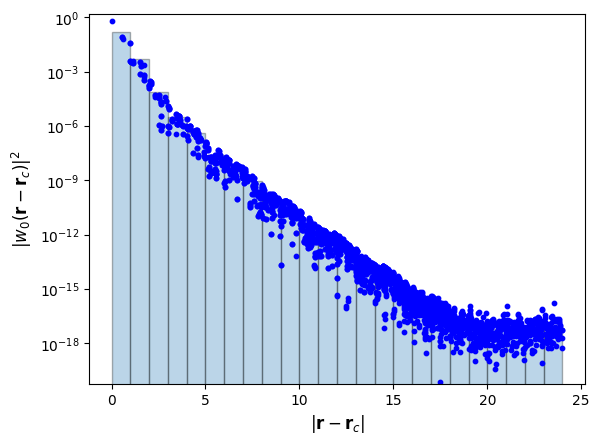

In [15]:
fig, ax = WF.plot_decay(0, show=True)

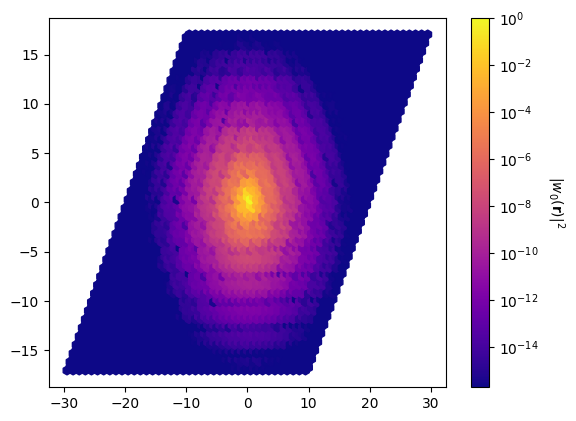

In [16]:
fig, ax = WF.plot_density(0, show=True)

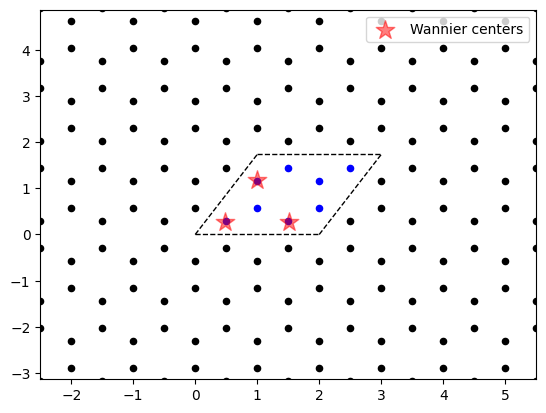

In [17]:
fig, ax = WF.plot_centers(color_home_cell=True, center_scale=15, legend=True, pmx=4, pmy=4, show=True)

In [18]:
k_nodes = [[0, 0], [2/3, 1/3], [1/2, 1/2], [1/3, 2/3], [0, 0], [1/2, 1/2]]
k_label = (r'$\Gamma $',r'$K$', r'$M$', r'$K^\prime$', r'$\Gamma $', r'$M$')

In [19]:
n_interp = 501
interp_energies = WF.interp_bands(k_nodes, n_interp=n_interp, ret_eigvecs=False)

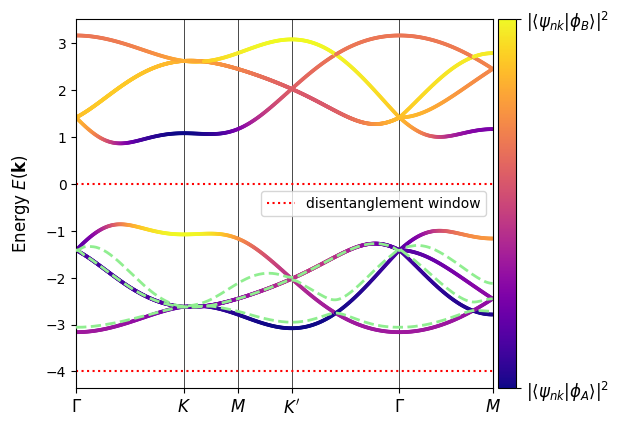

In [20]:
fig, ax = model.plot_bands(k_nodes=k_nodes, nk=501, k_node_labels=k_label, proj_orb_idx=high_E_sites, cmap='plasma')

(k_vec, k_dist, k_node) = model.k_path(k_nodes, nk=n_interp, report=False)
ax.plot(k_dist, interp_energies, ls='--', c='lightgreen', lw=2, zorder=5, alpha=1)

# plot windows
if frozen_window is not None:
    ax.axhline(frozen_window[0], ls='--', c='b', label='frozen window')
    ax.axhline(frozen_window[1], ls='--', c='b')

ax.axhline(outer_window[0], ls=':', c='r', label='disentanglement window')
ax.axhline(outer_window[1], ls=':', c='r')
ax.legend()